In [ ]:
import torch
from torch.utils.data import DataLoader, random_split
from torch.optim import Adam
from torchvision import transforms
from info_nce import InfoNCE

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

import sqlite3
import pandas as pd

from pathlib import Path
import sys

ROOT = Path.cwd().parents[1]
sys.path.append(str(ROOT))

from src.config.paths import EMBEDS_DIR, RESULTS, DB_PATH, MODEL_DIR
EMBED_PATH = EMBEDS_DIR/ "cont_embeds.pt"
EMBED_NAME = EMBED_PATH.stem

RESULTS_DIR = RESULTS / EMBED_NAME

In [3]:
contrastive_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [4]:
conn = sqlite3.connect(DB_PATH)

df = pd.read_sql_query("""
    SELECT path, split
    FROM meta
""", conn)

conn.close()

train_paths = df[df["split"] == "train"]["path"].to_list()
test_paths = df[df["split"] != "train"]["path"].to_list()

In [5]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

2.11.0+cu128
12.8
True
1


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {device}")

Device: cuda


In [7]:
dino = torch.hub.load(
            "facebookresearch/dinov2",
            "dinov2_vits14"
        )

dino.to(device)
dino.eval()

for p in dino.parameters():
    p.requires_grad = False

Using cache found in C:\Users\niall/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\niall/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\niall/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\niall/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [8]:
%load_ext autoreload
%autoreload 2

from src.fine_tune import ModelData, ProjectionHead, train_one_epoch, evaluate


In [ ]:
BATCH_SIZE = 256
NUM_WORKERS = 8
PIN_MEMORY = device == "cuda"

In [16]:
dataset = ModelData(train_paths, root=ROOT, transform=contrastive_transform)
test_set = ModelData(test_paths, root=ROOT, transform=test_transform)

train_split = int(len(dataset) * 0.95)
val_split = len(dataset) - train_split

generator = torch.Generator().manual_seed(42)

train_set, val_set = random_split(
    dataset,
    [train_split, val_split],
    generator=generator
)

train_loader = DataLoader(
        train_set,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [17]:
epochs = 10

model = ProjectionHead(dim=384).to(device)

optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = InfoNCE()

In [18]:
losses = {"train" : [], "val" : []}

for epoch in tqdm(range(epochs)):
    train_loss = train_one_epoch(model, dino, train_loader, criterion, optimizer, device)
    val_loss = evaluate(model, dino, val_loader, criterion, device)

    losses["train"].append(train_loss)
    losses["val"].append(val_loss)

    print("Train Loss:", train_loss)
    print("Val Loss:", val_loss)
  

  0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: 1.168797931185475
Val Loss: 0.9469683766365051
Train Loss: 0.9787196064436877
Val Loss: 0.8534092903137207
Train Loss: 0.8918914949452436
Val Loss: 0.8681638439496359
Train Loss: 0.8712577786710527
Val Loss: 0.7687813838322958
Train Loss: 0.8269064867938006
Val Loss: 0.7997430364290873
Train Loss: 0.8124289291876333
Val Loss: 0.7031897306442261
Train Loss: 0.8005825667469589
Val Loss: 0.6702388028303782
Train Loss: 0.7707215735205898
Val Loss: 0.7157448927561442
Train Loss: 0.7706722263936643
Val Loss: 0.7286133766174316
Train Loss: 0.7687448710203171
Val Loss: 0.6699389119942983


In [24]:
torch.save(model.state_dict(), MODEL_DIR / "best_model.pt")

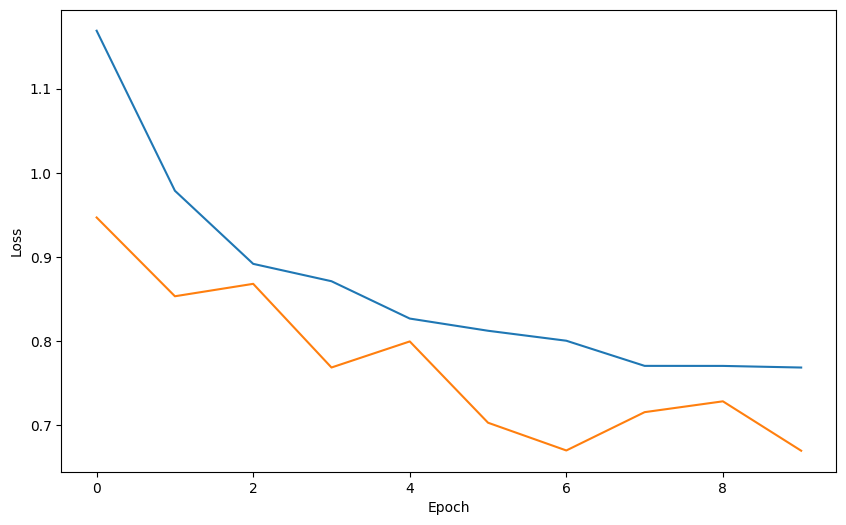

In [22]:
fig = plt.figure(figsize=(10, 6))

plt.plot(range(epochs), losses["train"])
plt.plot(range(epochs), losses["val"])

plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.show()